In [1]:
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications.efficientnet import preprocess_input

2026-05-06 15:24:53.505404: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778081093.832427      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778081093.939541      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778081094.779070      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778081094.779131      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778081094.779134      57 computation_placer.cc:177] computation placer alr

In [2]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [3]:
# PATH & LOAD DATA
dataset_dir = '/kaggle/input/datasets/troykueh/real-vs-fake-faces-stylegan3'

images = []
labels = []
class_names = ['Fake', 'Real']
class_folders = ['Fake faces', 'Real faces']

for idx, folder in enumerate(class_folders):
    folder_path = os.path.join(dataset_dir, folder)
    for img_name in os.listdir(folder_path):
        if img_name.lower().endswith('.png'):
            images.append(os.path.join(folder_path, img_name))
            labels.append(idx)

images = np.array(images)
labels = np.array(labels)

print(f"Total gambar  : {len(images)}")
print(f"Fake faces    : {np.sum(labels == 0)}")
print(f"Real faces    : {np.sum(labels == 1)}")

Total gambar  : 20000
Fake faces    : 10000
Real faces    : 10000


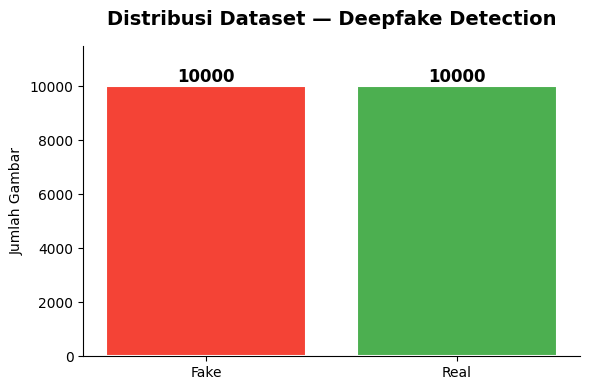

In [4]:
counts = [np.sum(labels == 0), np.sum(labels == 1)]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_names, counts, color=['#F44336', '#4CAF50'], edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Distribusi Dataset — Deepfake Detection', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Jumlah Gambar')
ax.set_ylim(0, max(counts) * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz1_distribusi_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

Train : 14000 | Val : 3000 | Test : 3000


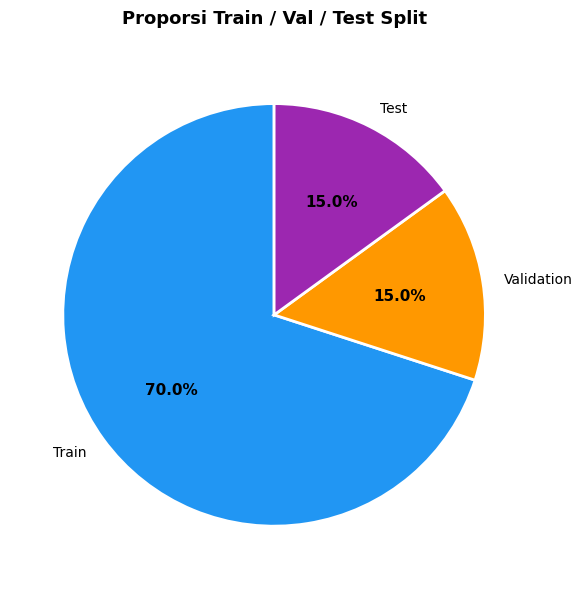

In [6]:
split_labels = ['Train', 'Validation', 'Test']
split_sizes  = [len(X_train), len(X_val), len(X_test)]
colors       = ['#2196F3', '#FF9800', '#9C27B0']
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    split_sizes, labels=split_labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax.set_title('Proporsi Train / Val / Test Split', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz3_data_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [8]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=25.5)   
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 255.0)                 
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

I0000 00:00:1778081131.780927      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [9]:
def build_model(fine_tune=False):
    base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    if not fine_tune:
        base_model.trainable = False
    else:
        base_model.trainable = True
        for layer in base_model.layers[:-30]:
            layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.6)(x)
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)
    return Model(base_model.input, output)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

In [10]:
print("\n=== Stage 1: Training Head ===")
model = build_model(fine_tune=False)
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)


=== Stage 1: Training Head ===
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/25


I0000 00:00:1778081156.540314     126 service.cc:152] XLA service 0x787a0c299710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778081156.540357     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778081160.141851     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778081178.204830     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


875/875 ━━━━━━━━━━━━━━━━━━━━ 98s 66ms/step - accuracy: 0.5722 - loss: 1.7414 - val_accuracy: 0.6763 - val_loss: 1.5248 - learning_rate: 1.0000e-04
Epoch 2/25
875/875 ━━━━━━━━━━━━━━━━━━━━ 36s 39ms/step - accuracy: 0.6699 - loss: 1.4834 - val_accuracy: 0.6993 - val_loss: 1.3436 - learning_rate: 1.0000e-04
Epoch 3/25
875/875 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - accuracy: 0.6980 - loss: 1.3103 - val_accuracy: 0.7240 - val_loss: 1.1971 - learning_rate: 1.0000e-04
Epoch 4/25
875/875 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - accuracy: 0.7101 - loss: 1.1736 - val_accuracy: 0.7300 - val_loss: 1.0831 - learning_rate: 1.0000e-04
Epoch 5/25
875/875 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - accuracy: 0.7237 - loss: 1.0557 - val_accuracy: 0.7243 - val_loss: 0.9988 - learning_rate: 1.0000e-04
Epoch 6/25
875/875 ━━━━━━━━━━━━━━━━━━━━ 36s 39ms/step - accuracy: 0.7362 - loss: 0.9674 - val_accuracy: 0.7350 - val_loss: 0.9193 - learning_rate: 1.0000e-04
Epoch 7/25
875/875 ━━━━━━━━━━━━━━━━━━━━ 36s 39ms/step - accurac

In [11]:
model.save('/kaggle/working/model_stage1.keras')
print("Model Stage 1 tersimpan!")

Model Stage 1 tersimpan!


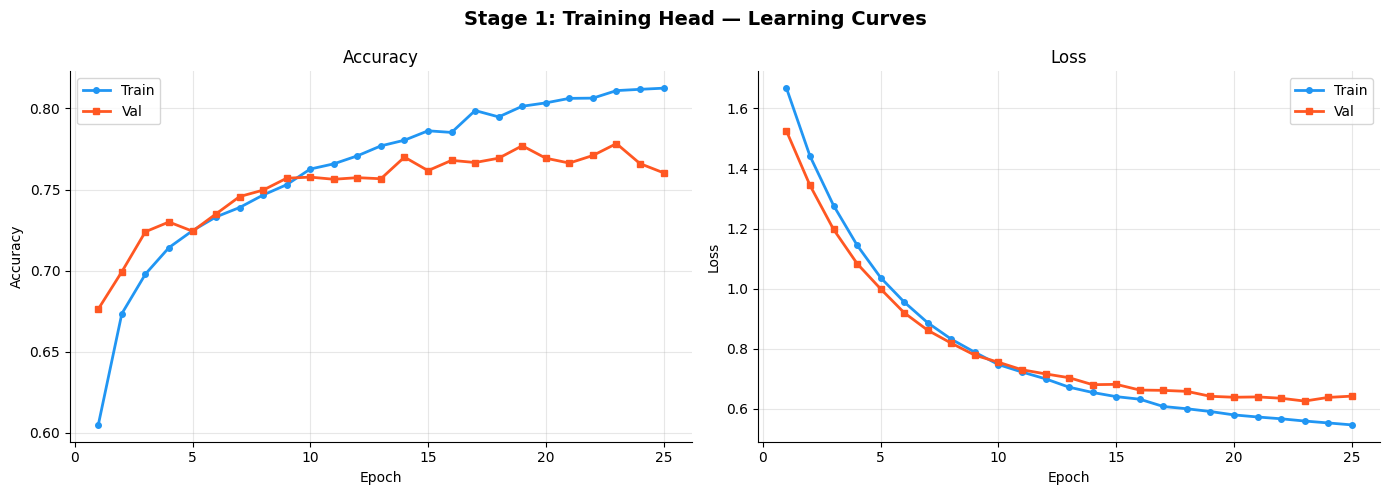

In [12]:
#Learning Curve Stage-1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 1: Training Head — Learning Curves', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs_ran, history.history['accuracy'],     'o-', color='#2196F3', label='Train', linewidth=2, markersize=4)
ax1.plot(epochs_ran, history.history['val_accuracy'], 's-', color='#FF5722', label='Val',   linewidth=2, markersize=4)
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3); ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(epochs_ran, history.history['loss'],     'o-', color='#2196F3', label='Train', linewidth=2, markersize=4)
ax2.plot(epochs_ran, history.history['val_loss'], 's-', color='#FF5722', label='Val',   linewidth=2, markersize=4)
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3); ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz4_stage1_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
for i, layer in enumerate(model.layers):
    has_layers = hasattr(layer, 'layers')
    n_layers = len(layer.layers) if has_layers else 0
    print(f"[{i}] {layer.name} — {type(layer).__name__} — has_layers={has_layers} — n={n_layers}")

[0] input_layer — InputLayer — has_layers=False — n=0
[1] rescaling — Rescaling — has_layers=False — n=0
[2] normalization — Normalization — has_layers=False — n=0
[3] rescaling_1 — Rescaling — has_layers=False — n=0
[4] stem_conv_pad — ZeroPadding2D — has_layers=False — n=0
[5] stem_conv — Conv2D — has_layers=False — n=0
[6] stem_bn — BatchNormalization — has_layers=False — n=0
[7] stem_activation — Activation — has_layers=False — n=0
[8] block1a_dwconv — DepthwiseConv2D — has_layers=False — n=0
[9] block1a_bn — BatchNormalization — has_layers=False — n=0
[10] block1a_activation — Activation — has_layers=False — n=0
[11] block1a_se_squeeze — GlobalAveragePooling2D — has_layers=False — n=0
[12] block1a_se_reshape — Reshape — has_layers=False — n=0
[13] block1a_se_reduce — Conv2D — has_layers=False — n=0
[14] block1a_se_expand — Conv2D — has_layers=False — n=0
[15] block1a_se_excite — Multiply — has_layers=False — n=0
[16] block1a_project_conv — Conv2D — has_layers=False — n=0
[17] bloc

In [17]:
# Stage 2: Fine-tuning — lanjut dari model Stage 1
print("\n=== Stage 2: Fine-tuning ===")

model = tf.keras.models.load_model('/kaggle/working/model_stage1.keras')

# Total layer backbone = 385 (index 0-384)
# Buka 30 layer terakhir backbone (index 355-384)
BACKBONE_END = 385
UNFREEZE_FROM = BACKBONE_END - 30  # = 355

for i, layer in enumerate(model.layers):
    if i < UNFREEZE_FROM:
        layer.trainable = False
    else:
        layer.trainable = True

trainable = sum(1 for l in model.layers if l.trainable)
frozen    = sum(1 for l in model.layers if not l.trainable)
print(f"Trainable: {trainable} | Frozen: {frozen}")

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)


=== Stage 2: Fine-tuning ===
Trainable: 36 | Frozen: 355
Epoch 1/15


2026-05-06 15:49:00.875997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 15:49:01.092562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 15:49:01.742553: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 15:49:02.002669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


875/875 ━━━━━━━━━━━━━━━━━━━━ 106s 67ms/step - accuracy: 0.6841 - loss: 0.8686 - val_accuracy: 0.7397 - val_loss: 0.7034 - learning_rate: 1.0000e-05
Epoch 2/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.7592 - loss: 0.6484 - val_accuracy: 0.7560 - val_loss: 0.6669 - learning_rate: 1.0000e-05
Epoch 3/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.7890 - loss: 0.6013 - val_accuracy: 0.7647 - val_loss: 0.6467 - learning_rate: 1.0000e-05
Epoch 4/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.7986 - loss: 0.5769 - val_accuracy: 0.7710 - val_loss: 0.6333 - learning_rate: 1.0000e-05
Epoch 5/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.8112 - loss: 0.5533 - val_accuracy: 0.7753 - val_loss: 0.6196 - learning_rate: 1.0000e-05
Epoch 6/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.8202 - loss: 0.5384 - val_accuracy: 0.7810 - val_loss: 0.6061 - learning_rate: 1.0000e-05
Epoch 7/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accura

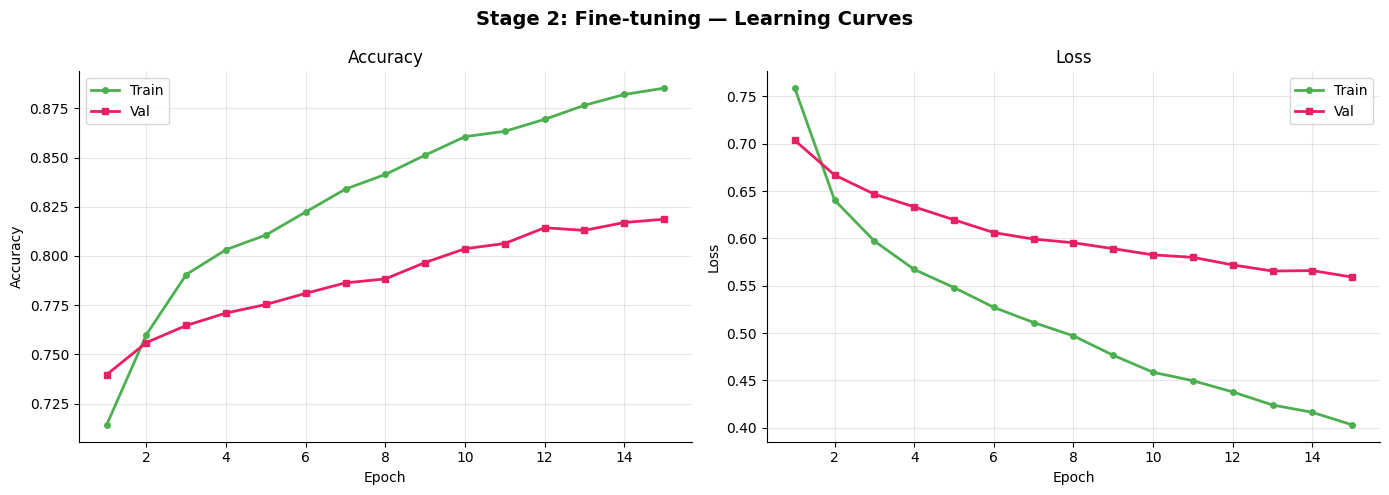

In [18]:
#LEARNING CURVE STAGE 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 2: Fine-tuning — Learning Curves', fontsize=14, fontweight='bold')

epochs_ran_ft = range(1, len(history_ft.history['accuracy']) + 1)

ax1.plot(epochs_ran_ft, history_ft.history['accuracy'],     'o-', color='#4CAF50', label='Train', linewidth=2, markersize=4)
ax1.plot(epochs_ran_ft, history_ft.history['val_accuracy'], 's-', color='#E91E63', label='Val',   linewidth=2, markersize=4)
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3); ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(epochs_ran_ft, history_ft.history['loss'],     'o-', color='#4CAF50', label='Train', linewidth=2, markersize=4)
ax2.plot(epochs_ran_ft, history_ft.history['val_loss'], 's-', color='#E91E63', label='Val',   linewidth=2, markersize=4)
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3); ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz5_stage2_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# EVALUASI TEST SET
print("\n=== Test Set Evaluation ===")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

y_pred_prob = model.predict(test_ds).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = y_test

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))


=== Test Set Evaluation ===
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.8271 - loss: 0.5323
Test Accuracy : 0.8163
Test Loss     : 0.5482
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 82ms/step

Classification Report:
              precision    recall  f1-score   support

        Fake       0.81      0.83      0.82      1500
        Real       0.83      0.80      0.81      1500

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



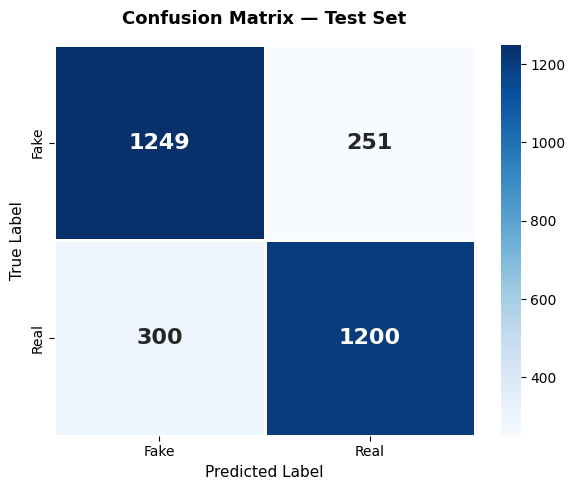

In [20]:
# CONFUSION MATRIX 
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('viz6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

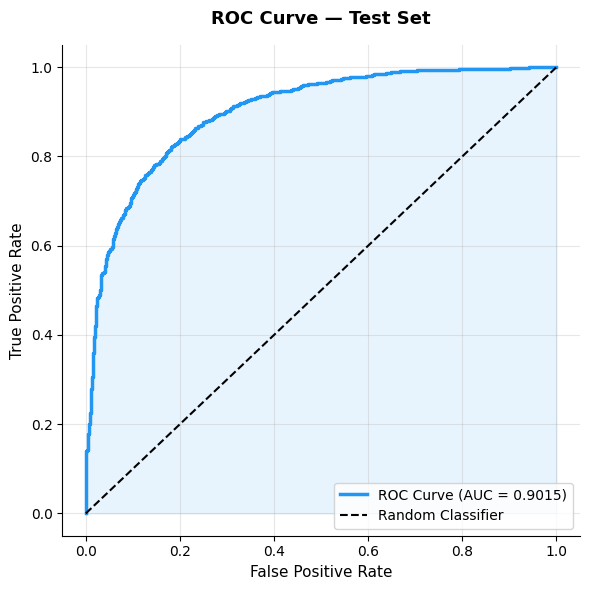

In [21]:
# ROC CURVE
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Test Set', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz7_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

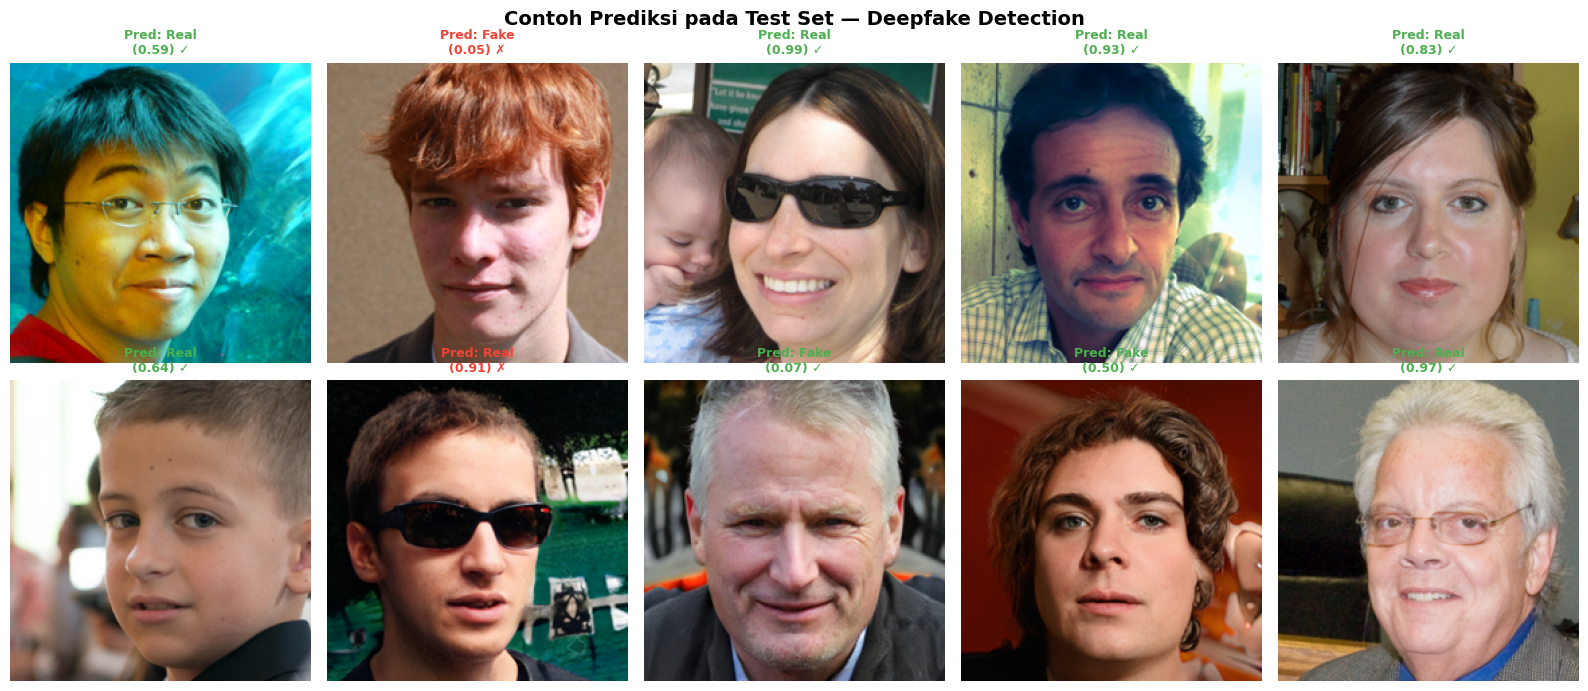

In [22]:
#PREDICTION RESULT
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Contoh Prediksi pada Test Set — Deepfake Detection', fontsize=14, fontweight='bold')

test_images_raw = []
for img_path in X_test[:10]:
    img = Image.open(img_path).resize((224, 224))
    test_images_raw.append(img)

for i, (img, true_lbl) in enumerate(zip(test_images_raw, y_test[:10])):
    row, col = divmod(i, 5)
    ax = axes[row, col]
    ax.imshow(img)
    ax.axis('off')
    pred_lbl  = y_pred[i]
    pred_prob = y_pred_prob[i]
    correct   = pred_lbl == true_lbl
    color     = '#4CAF50' if correct else '#F44336'
    ax.set_title(
        f"Pred: {class_names[pred_lbl]}\n({pred_prob:.2f}) {'✓' if correct else '✗'}",
        color=color, fontsize=9, fontweight='bold'
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('viz8_contoh_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()

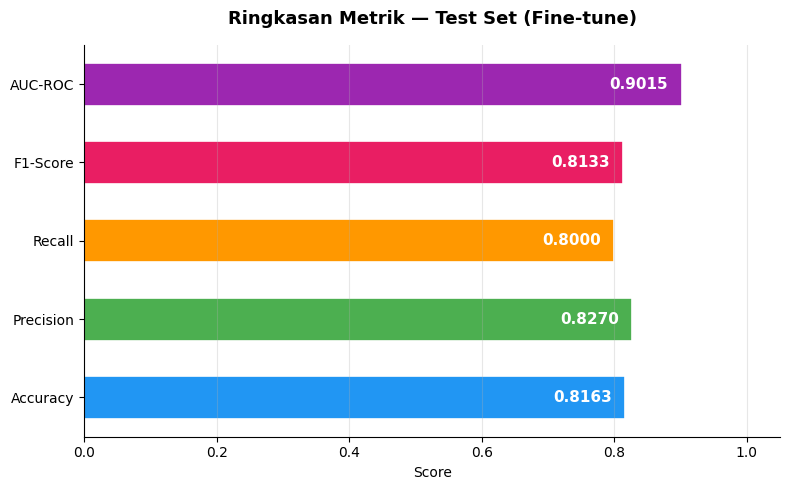

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'Accuracy' : test_acc,
    'Precision': precision_score(y_true, y_pred),
    'Recall'   : recall_score(y_true, y_pred),
    'F1-Score' : f1_score(y_true, y_pred),
    'AUC-ROC'  : roc_auc
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(list(metrics.keys()), list(metrics.values()),
               color=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0'],
               edgecolor='white', linewidth=1.2, height=0.55)
for bar, val in zip(bars, metrics.values()):
    ax.text(val - 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='right',
            color='white', fontweight='bold', fontsize=11)
ax.set_xlim(0, 1.05)
ax.set_title('Ringkasan Metrik — Test Set (Fine-tune)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Score')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('viz9_ringkasan_metrik.png', dpi=150, bbox_inches='tight')
plt.show()